In [24]:
from paldustransform import (
    NCounterBox, PaldusBox, PaldusStepBox, QRegMap,
    bitstring_to_vector, uga_gen, uga_gen_to_basis, uga_to_comp,
)
from pytket.circuit.display import render_circuit_jupyter
from IPython.display import display
import math
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg

np.set_printoptions(threshold=np.inf)

def array_to_latex(array, max_size=100):
    """Display an array without requiring Qiskit."""
    display(array)
    return array


In [2]:
def index_to_bitstring(index, length):
    """Convert an index to its corresponding bitstring representation of a given length."""
    return format(index, f'0{length}b')

def array_to_bitstring_mapping(arr):
    """Map an array's non-zero components to its bitstring index representation and value."""
    arr = arr.flatten()
    n = int(np.log2(len(arr)))
    non_zero_entries = {}

    for idx, val in enumerate(arr):
        if not np.isclose(val, 0):  # if the value is not close to zero
            bitstr = index_to_bitstring(idx, n)
            non_zero_entries[bitstr] = val

    # Convert dictionary to desired string format
    output = ", ".join(f"{k}: {v:.4f}" for k, v in non_zero_entries.items())
    return non_zero_entries #output

def ac_to_comp(ac: str, m: float):
    """Returns the computational basis vector of the given AC state.
    
    AC: The AC sequence of the state 
    m: The spin-z component of the state
    """
    test_sv = np.complex128(0) * np.zeros((1, 2 ** len(ac))).T
    state_list = uga_to_comp(ac, m)
    for state in state_list:
        bitstring, amplitude = state
        test_sv += amplitude * bitstring_to_vector(bitstring).T
    return test_sv

# The Quantum Paldus Transform

The Quantum Paldus Transform (QPT) is an algorithm for performing the change of basis from the spin-orbital occupation number representation to the eigenbasis of the total spin and spin projection. This is also referred to as the Quantum Unitary Group Approach (QUGA), and is a follow-up to a series of work by M. Moshinsky, J. Paldus and I. Shavitt, who applied these ideas to perform configuration interaction calculations for computational quantum chemistry. 

The QPT has many similarities to the Quantum Schur Transform. Formally, we can say it is an isometry between 

$\mathbb{C}^{2^{2d}} \ni |x_{1, \uparrow} \ x_{1, \downarrow} \ ... \ x_{n, \uparrow} \ x_{n, \downarrow} \rangle$, 

which is the space of $d$ spin-orbitals (which by the exclusion principle can house at most $2d$ electrons), and 

$\mathbb{C}^{2d+1} \otimes \mathbb{C}^{d+1} \otimes \mathbb{C}^{2d+1} \otimes \mathbb{C}^{2^{2d}} \ni |N \rangle \otimes |S \rangle \otimes |M \rangle \otimes |AC \rangle$, 

which is the product space of occupation number, spin, spin projection, AC states.

&nbsp;

Alternatively, we can say that the QPT realises the Howe Duality between the groups $SU(2)$ and $U(d)$ on the exterior algebra $\bigwedge(\mathbb{C}^{2} \otimes \mathbb{C}^d)$ (see [Theorem 3.10 here](https://arxiv.org/abs/2208.08979v1) and [here](https://www.cambridge.org/core/services/aop-cambridge-core/content/view/9EA17A35FC09112B7829EDD8ADF2485F/S0010437X01000549a.pdf/howe_duality_for_lie_superalgebras.pdf)). The exterior algebra of a vector space is [defined as](https://en.wikipedia.org/wiki/Exterior_algebra):

$\bigwedge(V) = \bigwedge^0(V) \oplus \bigwedge^1(V) \oplus ... = \bigoplus_{k=0}^\infty \bigwedge^k(V)$,

where $\bigwedge^k(V)$ is the $k$-th exterior power of $V$, and $\dim(\bigwedge^k(V)) = \binom{\dim V}{k}$ for $k \leq \dim V$, and $0$ otherwise. Howe Duality tells us that for a vector space $V$ and $W$, acted on by members $GL(U)$ and $GL(W)$, the exterior algebra of a product space $\bigwedge(U \otimes W)$ decomposes as:

$\bigwedge(U \otimes W) = \bigoplus_{\lambda} V^\lambda_U \otimes V^{\bar{\lambda}}_W$,

where $\lambda$ are Young Diagrams of length (row count) not exceeding no greater than $\dim U$ and width (column count) no greater than $\dim W$, and $\bar{\lambda}$ is its conjugate Young Diagram, obtained by flipping the rows and columns of $\lambda$. As we know, the irreducible representations of $GL(V)$ are indexed by the $\lambda$'s, and we can identify a basis for these irreps (the Gelfand-Tsetlin basis) which remains invariant under the action of $U(V)$ as well as $SU(V)$. If we pick $U = \mathbb{C}^2$ and $V = \mathbb{C}^d$, we can identify $\bigwedge(\mathbb{C}^2 \otimes \mathbb{C}^d) \simeq \bigwedge(\mathbb{C}^{2d})$ to be the Fock Space of $2d$ fermions (spin-orbitals) and $\lambda$ to be Young Diagrams of up to $2$ rows and $d$ columns. 

In this way, spin-free quantum chemistry and the UGA are a consequence of Howe Duality. If we view the QPT in this picture, the $|N \rangle \otimes |S \rangle \otimes | M \rangle $ states label states of $U(2)$ irreps, and the $|AC \rangle$ states label states of $U(d)$ irreps. Furthermore, different choices of $N, S$ are in one-to-one correspondence with Young Diagrams $(N/2 + S, N/2 - S)$ of $\leq 2$ rows and $\leq d$ columns, and choices of $M$ out of $2S+1$ particular values are in one-to-one correspondence with the Semi-Standard Young Tablaux (or Weyl Tableux) of this shape. On the other hand, the $AC$ registers can be shown to be in one-to-one correspondence with the Weyl Tableux of conjugate shape. This is because each $AC$ corresponds to a Gelfand-Tsetlin pattern, which in turn corresponds to a Weyl Tableux.

&nbsp;

The QPT is implemented in `paldustransform` as the `PaldusBox` class, which takes in the number of orbitals `d` as its parameter (with an additional toggle to enable/disable the occupation number storage register).

***

##### Some basic examples:

Below is a `PaldusBox` for 2 orbitals (4 qubits), along with 8 ancillary qubits for $N, S, M$ registers:

In [4]:
#paldus_box = PaldusBox(1).dagger
paldus_box = PaldusBox(2)

test_circ = paldus_box.initialise_circuit()
qreg_map = QRegMap(paldus_box.qubits, test_circ.qubits)
test_circ.add_registerbox(paldus_box,qreg_map)
render_circuit_jupyter(test_circ)

Below is a `PaldusBox` for 3 orbitals (6 qubits), along with 5 ancillary qubits for $S, M$ registers. We have disabled the $N$ register with the `occupation_reg=false` option (it is not required for performing the transform, but may nonetheless be useful for some applications).

In [5]:
paldus_box = PaldusBox(3, occupation_reg=False)

test_circ = paldus_box.initialise_circuit()
qreg_map = QRegMap(paldus_box.qubits, test_circ.qubits)
test_circ.add_registerbox(paldus_box,qreg_map)
render_circuit_jupyter(test_circ)


The $N$ register is updates using the `CounterBox` class, which in turn is a counter made of Incrementer Boxes. It effectively counts and stores the Hamming Weight of the input. An example for 3 qubits is below. 

In [6]:
counter_box = NCounterBox(3)

test_circ = counter_box.initialise_circuit()
qreg_map = QRegMap(counter_box.qubits, test_circ.qubits)
test_circ.add_registerbox(counter_box,qreg_map)
render_circuit_jupyter(test_circ)

The Paldus Transform is performed by a sequence of *"Paldus Step-Transforms"*, in the same way that the Schur Transform is a cascade of Clebsch-Gordan transforms. In fact, both serve the same purpose of spin-coupling, with the difference that the Paldus Transform permits the coupling of spin-0 states. 

An example of the `PaldusStepBox` is given below. The arguments `(5, 5)` indicate that this is the 5th step of the Paldus Transform for 5 orbitals. These inputs determine the number of controlled givens rotations performed by the Multiplexor Box in the box. The multiplexor conditions the controlled rotations on particular values of $S, M$, which are stored in binary in the ancillary register.

In [8]:
step_box = PaldusStepBox(5, 5)

test_circ = step_box.initialise_circuit()
qreg_map = QRegMap(step_box.qubits, test_circ.qubits)
test_circ.add_registerbox(step_box,qreg_map)
render_circuit_jupyter(test_circ)

The `PaldusBox` class comes with numerous methods; the ones we want to highlight here (which make reading the circuits useful) are `spin_to_binary`, `binary_to_spin`, `spin_z_to_binary`, `binary_to_spin_z`, `occupation_to_binary`, `binary_to_occupation`. These convert between the way the ancillas register values of $S, M, N$ in binary.

A few examples (for the ancillas in a 3-orbital transform):

In [9]:
paldus_box = PaldusBox(3)

print("S = 0.5 <->", paldus_box.spin_to_binary(0.5), " | S = 1.0 <->", paldus_box.spin_to_binary(1.0))
print("M = 0.5 <->", paldus_box.spin_z_to_binary(0.5), " | M = -1.0 <->", paldus_box.spin_z_to_binary(1.0))
print("N =", paldus_box.binary_to_occupation("100"), " <-> 100 | N = 7 <->" , paldus_box.occupation_to_binary(7))

S = 0.5 <-> 01  | S = 1.0 <-> 10
M = 0.5 <-> 001  | M = -1.0 <-> 010
N = 4  <-> 100 | N = 7 <-> 111


## Properties of the QUGA basis

The Quantum Unitary Group Approach is motivated by solving problems in chemistry where the Hamiltonian is spin-free, i.e. of the form:

$\hat{\mathcal{H}} = \sum_{i, j} \sum_\sigma z_{ij} X^\dagger_{i \sigma} X_{j \sigma} + \frac{1}{2} \sum_{i, j, k, l} \sum_{\sigma, \tau} v_{ij, kl} X^\dagger_{i \sigma} X^\dagger_{j \tau} X_{l \tau} X_{k \sigma} $

where $z_{ij} = \langle i | z | j \rangle$ and $v_{ij, kl} = \langle ij | v | kl \rangle$ are the one- and two-electron integrals, which we may take to be parameters of the Hamiltonian. The operators $X^\dagger_{i \sigma}$ and $X_{j \sigma}$ are the creation and annihilation operators for particles in the $i^{\text{th}}$ orbital with spin $\sigma$. We may take sums of products of these operators over the spatial and spin indices, to obtain two sets of operators:

$ \mathcal{E}_{\sigma_1 \sigma_2} = \sum_{i} X^\dagger_{i \sigma_1} X_{i \sigma_2}, \hspace{1cm} E_{i_1 i_2} = \sum_{\sigma} X^\dagger_{i_1 \sigma} X_{i_2 \sigma} $

These operators turn out to be the generators of the Lie algebras $su(2)$ and $u(d)$ respectively, and satisfy $[E_{i_1 i_2}, \mathcal{E}_{\sigma_1 \sigma_2}] = 0$.


#### Expressing lie algebra operators using the QUGA basis

We can implement the $su(2)$ and $u(d)$ algebras ladder operators in the spin-orbital basis using the Jordan-Wigner mapping:

In [11]:
def a_jw(d: int, i: int):
    """Returns a Jorda-Wigner annihilation operator on the ith qubit of 2d qubits. i € {1, ..., 2d}"""
    a = np.asarray([[0, 1],
                    [0, 0]])
    z = np.asarray([[1, 0],
                    [0, -1]])
    id = np.asarray([[1, 0],
                    [0, 1]])
    mat = 1

    for j in range(i-1):
        mat = np.kron(mat, z)

    mat = np.kron(mat, a)

    for j in range(2*d - i):
        mat = np.kron(mat, id)

    return mat

def e_d(d: int, i: int, j: int):
    """Returns a U(d) ladder operator E_ij on 2d qubits. i,j € {1, ..., d}"""

    mat = a_jw(d, 2*i - 1 ).conj().T @ a_jw(d, 2*j - 1) + a_jw(d, 2*i).conj().T @ a_jw(d, 2*j) 
    return mat

def e_2(n: int, i: float, j: float):
    """Returns a U(2) ladder operator e_ij on 2n qubits. i,j € {+1/2, -1/2}"""

    mat = 0
    for k in range(1, n+1):
        mat = mat + a_jw(n, 2*k - int(1/2 + i) ).conj().T @ a_jw(n, 2*k - int(1/2 + j) )
    return mat

def num_op(d: int):
    """Returns the number operator on 2d qubits."""
    mat = 0
    for i in range(1, d+1):
        mat = mat + e_d(d, i, i)
    return mat

def spin_z(d: int):
    """Returns the spin_z operator on 2d qubits."""
    return 0.5*(e_2(d, 0.5, 0.5) - e_2(d, -0.5, -0.5))

def spin(d: int):
    """S^2 operator on 2d qubits. Eigenvalues are s(s+1)."""
    return spin_z(d) @ (spin_z(d) + np.identity(2**(2*d))) + e_2(d, -0.5, 0.5) @ e_2(d, 0.5, -0.5)

Here is an example of a raising generator $E_{21}$ on $2$ orbitals (4 qubits):

In [12]:
array_to_latex(e_d(2, 2, 1), max_size = 100)

<IPython.core.display.Latex object>

These generators can be exponentiated into $U(n)$ gates on the occupation number basis. We can do this by finding exponentials of the combinations 

$E_{ij} - E_{ji}, \ \ \ i(E_{ij} + E_{ji})$ 

of the ladder operators. So an example $U(n)$ gate on $2$ spin-orbitals (4 qubits), in the computational basis, is:

In [13]:
array_to_latex(scipy.linalg.expm((e_d(2,1,2) - e_d(2,2,1))), max_size=100)

<IPython.core.display.Latex object>

We can see how these gates act in the UGA basis - they will indeed be block-diagonal. To do this, we find the UGA basis states:

In [14]:
uga_list = [('0000', 0, 0, 0),  
 ('0010', 1, 0.5, 0.5),
 ('1000', 1, 0.5, 0.5),
 ('0010', 1, 0.5, -0.5),
 ('1000', 1, 0.5, -0.5),
 ('1001', 2, 0.0, 0.0),
 ('1100', 2, 0, 0),
 ('0011', 2, 0, 0),
 ('1010', 2, 1.0, 1.0),
 ('1010', 2, 1.0, 0.0),
 ('1010', 2, 1.0, -1.0),
 ('1011', 3, 0.5, 0.5),
 ('1110', 3, 0.5, 0.5),
 ('1011', 3, 0.5, -0.5),
 ('1110', 3, 0.5, -0.5),
 ('1111', 4, 0, 0)]

state_list = []
for i in uga_list:
    state_list.append(ac_to_comp(i[0], i[3]))

And then, we find the matrix elements in this basis:

In [15]:
uga_gate = scipy.linalg.expm(e_d(2,1,2) - e_d(2,2,1))
gate_uga_basis = np.zeros((len(state_list), len(state_list)), dtype=complex)
for i in range(len(state_list)):
    for j in range(len(state_list)):
        uga_i = state_list[i]
        #uga_j = e_d(pbox.orbital_number, 2,1) @ state_list[j]
        uga_j = uga_gate @ state_list[j]
        #uga_j = #e_2(2, 0.5, -0.5) @ state_list[j]
        #uga_j = scipy.linalg.expm(e_2(2,0.5,-0.5) - e_2(2,-0.5,0.5)) @ state_list[j]
        gate_uga_basis[i,j] = np.vdot(uga_i, uga_j)

array_to_latex(gate_uga_basis, max_size=100)

<IPython.core.display.Latex object>

We can use the pre-select option in `unitary_postselect` to select onto different $N,S,M$ subspaces. But for simplicity, here we've constructed the full matrix by taking inner products. 

We can repeat this for $d=3$. Here, the blocks are 'ordered' as in the following diagram.

<img src="https://i.imgur.com/dVQH9G0.png" width=500 height=500 />

We can reproduce the diagram by calculating matrix elements of the spin-free hamiltonian in the UGA basis, and then creating a colour map of the resulting matrix (we display the absolute value of the matrix elements, as the matrix is complex).

You can see it looks just like the plot! This tells us that the UGA basis does indeed behave the way it should. 

In [22]:
#Arrangement with respect to U(d) irreps

uga_list_d3 = [('000000', 0, 0),
('000010', 1, 0.5),
('001000', 1, 0.5),
('100000', 1, 0.5),  
('000010', 1, -0.5),
('001000', 1, -0.5),
('100000', 1, -0.5),  
('000011', 2, 0.0),
('001001', 2, 0.0),
('001100', 2, 0.0),
('100001', 2, 0.0),
('100100', 2, 0.0),
('110000', 2, 0.0),
('001010', 2, 1.0),
('100010', 2, 1.0),
('101000', 2, 1.0),
('001010', 2, 0.0),
('100010', 2, 0.0),
('101000', 2, 0.0),
('001010', 2, -1.0),
('100010', 2, -1.0),
('101000', 2, -1.0),
('001011', 3, 0.5),
('001110', 3, 0.5),
('100011', 3, 0.5),
('100110', 3, 0.5),
('101001', 3, 0.5),
('101100', 3, 0.5),
('110010', 3, 0.5),
('111000', 3, 0.5),
('001011', 3, -0.5),
('001110', 3, -0.5),
('100011', 3, -0.5),
('100110', 3, -0.5),
('101001', 3, -0.5),
('101100', 3, -0.5),
('110010', 3, -0.5),
('111000', 3, -0.5),
('101010', 3, 1.5),
('101010', 3, 0.5),
('101010', 3, -0.5),
('101010', 3, -1.5),
('111100', 4, 0.0),
('111001', 4, 0.0),
('110011', 4, 0.0),
('101101', 4, 0.0),
('100111', 4, 0.0),
('001111', 4, 0.0),
('101011', 4, 1.0),
('101110', 4, 1.0),
('111010', 4, 1.0),
('101011', 4, 0.0),
('101110', 4, 0.0),
('111010', 4, 0.0),
('101011', 4, -1.0),
('101110', 4, -1.0),
('111010', 4, -1.0),
('101111', 5, 0.5),
('111011', 5, 0.5),
('111110', 5, 0.5),
('101111', 5, -0.5),
('111011', 5, -0.5),
('111110', 5, -0.5),
('111111', 6, 0)]

state_list_d3 = []
for i in uga_list_d3:
    state_list_d3.append(ac_to_comp(i[0], i[2]))

# Calculate the matrix

uga_gate_d3 = scipy.linalg.expm(e_d(3,1,2) - e_d(3,2,1) + 1j*e_d(3, 2, 3) + 1j*e_d(3, 3, 2))
gate_uga_basis_d3 = np.zeros((len(state_list_d3), len(state_list_d3)), dtype=complex)
for i in range(len(state_list_d3)):
    for j in range(len(state_list_d3)):
        uga_i = state_list_d3[i]
        uga_j = uga_gate_d3 @ state_list_d3[j]
        gate_uga_basis_d3[i,j] = np.vdot(uga_i, uga_j)

array_to_latex(gate_uga_basis_d3, max_size=100) # This generates a huge matrix, which we display with a colour map instead. 

<IPython.core.display.Latex object>

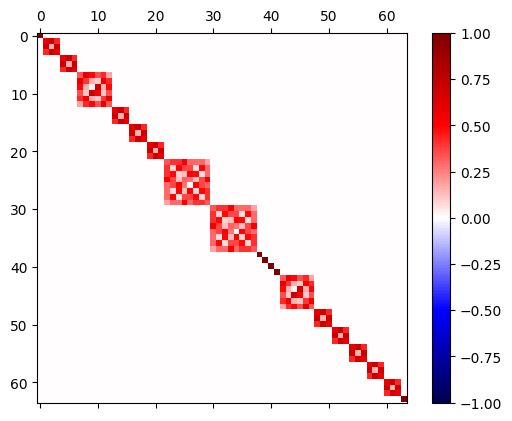

In [28]:
matrix = gate_uga_basis_d3


fig, ax = plt.subplots()
cax = ax.matshow(np.abs(matrix), cmap='seismic', vmin=-1, vmax=1)
fig.colorbar(cax)

plt.show()